# This notebook will perform exploratory data analysis on the Training data for this Kaggle train dataset.

In [23]:
# Setup file contains library imports and file paths for data
from _Setup import * 

In [24]:
# Load in the training data
train = pd.read_json(train_path)

The training data contains 5 columns and 6807 documents. The definitions of each column is as follows:

document (int) -- an integer ID of the essay

full_text (string) -- a UTF-8 representation of the essay

tokens (list) -- a string representation of each token

trailing_whitespace (list) -- boolean value indicating whether each token is followed by whitespace

labels (list) -- a token label in BIO format

BIO format is describe as (Beginning, Inner, Outer) format. PII will be prefixed with "B-" when at the beginning of an entity. "I-" prefixes denote token that are a continuation of an entity. "O" indicates non-PII tokens.

In [25]:
train.head(5)

,document,full_text,tokens,trailing_whitespace,labels
0,7,Design Thinking for innovation reflexion-Avril...,"[Design, Thinking, for, innovation, reflexion,...","[True, True, True, True, False, False, True, F...","[O, O, O, O, O, O, O, O, O, B-NAME_STUDENT, I-..."
1,10,Diego Estrada\n\nDesign Thinking Assignment\n\...,"[Diego, Estrada, \n\n, Design, Thinking, Assig...","[True, False, False, True, True, False, False,...","[B-NAME_STUDENT, I-NAME_STUDENT, O, O, O, O, O..."
2,16,Reporting process\n\nby Gilberto Gamboa\n\nCha...,"[Reporting, process, \n\n, by, Gilberto, Gambo...","[True, False, False, True, True, False, False,...","[O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O..."
3,20,Design Thinking for Innovation\n\nSindy Samaca...,"[Design, Thinking, for, Innovation, \n\n, Sind...","[True, True, True, False, False, True, False, ...","[O, O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT..."
4,56,Assignment: Visualization Reflection Submitt...,"[Assignment, :, , Visualization, , Reflecti...","[False, False, False, False, False, False, Fal...","[O, O, O, O, O, O, O, O, O, O, O, O, B-NAME_ST..."


In [26]:
print(train.shape)

(6807, 5)


Let's look closer into some examples of PII with "B" and "I" prefixes. 

In this document, the only PII in the document was the name of the student, denoted by B-NAME_STUDENT and I-NAME_STUDENT. We can see that B-NAME_STUDENT refers to first name of the student (Beginning) while the last name is a continuation of the token so it is labeled as I-NAME_STUDENT. 

In [27]:
train_example = train.iloc[0]
example_tokens = train_example['tokens']
example_labels = train_example['labels']

# Create a boolean vector for labels that are 'B-NAME_STUDENT' or 'I-NAME_STUDENT'
is_name_student = [label in ['B-NAME_STUDENT', 'I-NAME_STUDENT'] for label in example_labels]

# Extract the corresponding tokens
name_student_tokens = [token for token, is_name in zip(example_tokens, is_name_student) if is_name]

print(name_student_tokens)

['Nathalie', 'Sylla', 'Nathalie', 'Sylla', 'Nathalie', 'Sylla']


This is an example of a B-USERNAME for a student. While "fdixon" may look like gibberish outside of the English language, usernames will generally not have a pre-trained embedding if we use BERT, but this is part of the complicated problem of identifying PII. 

In [28]:
train_example1 = train.iloc[194]

example_tokens1 = train_example1['tokens']
example_labels1 = train_example1['labels']  

is_PII = [label in ['B-USERNAME'] for label in example_labels1]
pii_tokens = [token for token, is_pii in zip(example_tokens1, is_PII) if is_pii]

print(pii_tokens)




['fdixon', 'fdixon']


Examples of PII labeled as an ID number, which might look like a random jumble of numbers and is also longer than a phone number. Will likely depend on other PII around it, such as writing student name nearby ID number. 

In [29]:
train_example1 = train.iloc[366]

example_tokens1 = train_example1['tokens']
example_labels1 = train_example1['labels']  

is_PII = [label in ['B-ID_NUM'] for label in example_labels1]
pii_tokens = [token for token, is_pii in zip(example_tokens1, is_PII) if is_pii]

print(pii_tokens)


['141774671173', '747051878431']


This is an example of B-EMAIL, pretty recognizable from the @hotmail.com to a regular person. We'll see if a model can piece together the fact that @ symbols followed by a .com will likely point to email addresses.

In [30]:
train_example1 = train.iloc[376]

example_tokens1 = train_example1['tokens']
example_labels1 = train_example1['labels']  

is_PII = [label in ['B-EMAIL'] for label in example_labels1]
pii_tokens = [token for token, is_pii in zip(example_tokens1, is_PII) if is_pii]

print(pii_tokens)


['johnsondavid@hotmail.com', 'johnsondavid@hotmail.com']


Another PII labeled as personal URL, while every link won't be PII, the model will have to recognize certain patterns in tokens labelled as B-PERSONAL_URL. 

In [31]:
train_example1 = train.iloc[380]

example_tokens1 = train_example1['tokens']
example_labels1 = train_example1['labels']  

is_PII = [label in ['B-URL_PERSONAL'] for label in example_labels1]
pii_tokens = [token for token, is_pii in zip(example_tokens1, is_PII) if is_pii]

print(pii_tokens)


['http://mcdonald-pope.com/categorycategory.jsp']


Phone numbers are formatted such that the first parenthesis are considered B-PHONE_NUM and the first 6 digits and closing paranthesis is I-PHONE_NUM. Dash marks are also considered a separate token labelled I-PHONE_NUM. Finally, the last four digits and the extension is labeled I-PHONE_NUM, as well.

In [ ]:
# Find indices where 'B-PHONE_NUM' exists in the labels list
phone_num_indices = [index for index, labels in enumerate(train['labels']) if 'B-PHONE_NUM' in labels]

print("Indices containing 'B-PHONE_NUM':", phone_num_indices)

Indices containing 'B-PHONE_NUM': [185, 219, 350, 1103]


In [39]:
train_example1 = train.iloc[350]

example_tokens1 = train_example1['tokens']
example_labels1 = train_example1['labels']  

# Extract tokens and their corresponding labels for 'B-PHONE_NUM' and 'I-PHONE_NUM'
pii_tokens_with_labels = [(token, label) for token, label in zip(example_tokens1, example_labels1) if label in ['B-PHONE_NUM', 'I-PHONE_NUM']]

print(pii_tokens_with_labels)



[('(', 'B-PHONE_NUM'), ('820)913', 'I-PHONE_NUM'), ('-', 'I-PHONE_NUM'), ('3241x894', 'I-PHONE_NUM'), ('(', 'B-PHONE_NUM'), ('820)913', 'I-PHONE_NUM'), ('-', 'I-PHONE_NUM'), ('3241x894', 'I-PHONE_NUM'), ('(', 'B-PHONE_NUM'), ('820)913', 'I-PHONE_NUM'), ('-', 'I-PHONE_NUM'), ('3241x894', 'I-PHONE_NUM')]


In [38]:
train_example1 = train.iloc[185]

example_tokens1 = train_example1['tokens']
example_labels1 = train_example1['labels']  

is_PII = [label in ['B-PHONE_NUM', 'I-PHONE_NUM'] for label in example_labels1]
pii_tokens = [token for token, is_pii in zip(example_tokens1, is_PII) if is_pii]

print(pii_tokens)

['(', '320)202', '-', '0688x95843']


In [40]:
# Find indices where 'B-PHONE_NUM' exists in the labels list
street_indices = [index for index, labels in enumerate(train['labels']) if 'B-STREET_ADDRESS' in labels]

print("Indices containing 'B-STREET_ADDRESS':", street_indices)

Indices containing 'B-STREET_ADDRESS': [1103, 1887]


Street addresses are separated into multiple tokens that follow the leading token labelled B-STREET_ADRESS. It will be important for the model to determine the end of the street address, which is most commonly the 5 digit zip code.

In [42]:
train_example1 = train.iloc[1103]

example_tokens1 = train_example1['tokens']
example_labels1 = train_example1['labels']  

# Extract tokens and their corresponding labels for 
pii_tokens_with_labels = [(token, label) for token, label in zip(example_tokens1, example_labels1) if label in ['B-STREET_ADDRESS', 'I-STREET_ADDRESS']]

print(pii_tokens_with_labels)


[('591', 'B-STREET_ADDRESS'), ('Smith', 'I-STREET_ADDRESS'), ('Centers', 'I-STREET_ADDRESS'), ('Apt', 'I-STREET_ADDRESS'), ('.', 'I-STREET_ADDRESS'), ('656', 'I-STREET_ADDRESS'), ('\n', 'I-STREET_ADDRESS'), ('Joshuamouth', 'I-STREET_ADDRESS'), (',', 'I-STREET_ADDRESS'), ('RI', 'I-STREET_ADDRESS'), ('95963', 'I-STREET_ADDRESS')]


Let's visualize the number of documents for each type of PII.

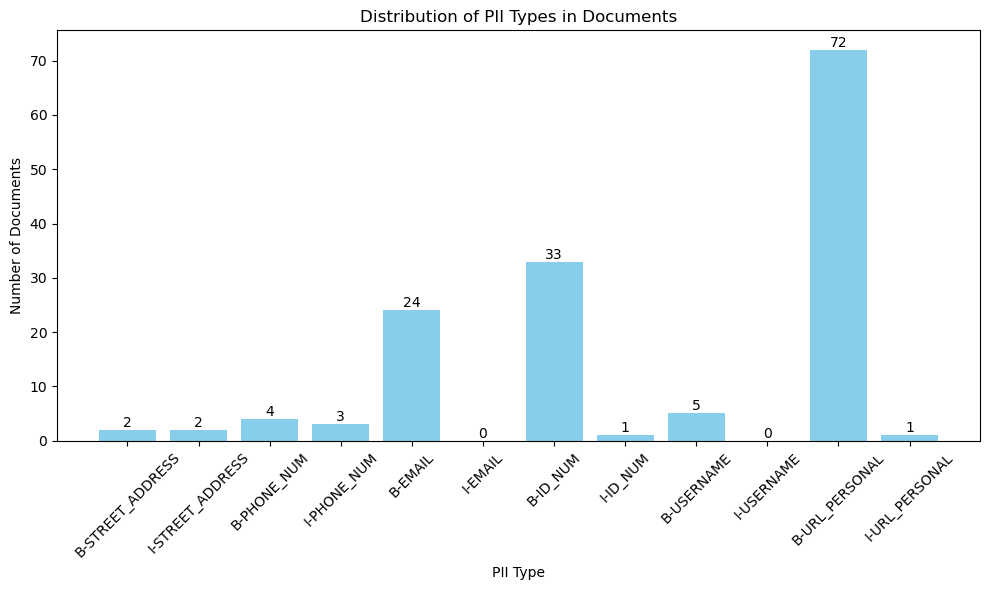

In [45]:
import matplotlib.pyplot as plt

# Define the list of PII types to count
pii_types = ['B-STREET_ADDRESS', 'I-STREET_ADDRESS', 'B-PHONE_NUM','I-PHONE_NUM', 'B-EMAIL','I-EMAIL', 'B-ID_NUM', 'I-ID_NUM', 'B-USERNAME', 'I-USERNAME', 'B-URL_PERSONAL', 'I-URL_PERSONAL']

# Count the number of documents containing each PII type
pii_counts = {pii: sum(pii in labels for labels in train['labels']) for pii in pii_types}

# Convert the counts to a DataFrame for easier plotting
pii_counts_df = pd.DataFrame(list(pii_counts.items()), columns=['PII Type', 'Document Count'])

# Plot the distribution of PII types
plt.figure(figsize=(10, 6))
bars = plt.bar(pii_counts_df['PII Type'], pii_counts_df['Document Count'], color='skyblue')

# Add counts on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(height), ha='center', va='bottom')

plt.xlabel('PII Type')
plt.ylabel('Number of Documents')
plt.title('Distribution of PII Types in Documents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

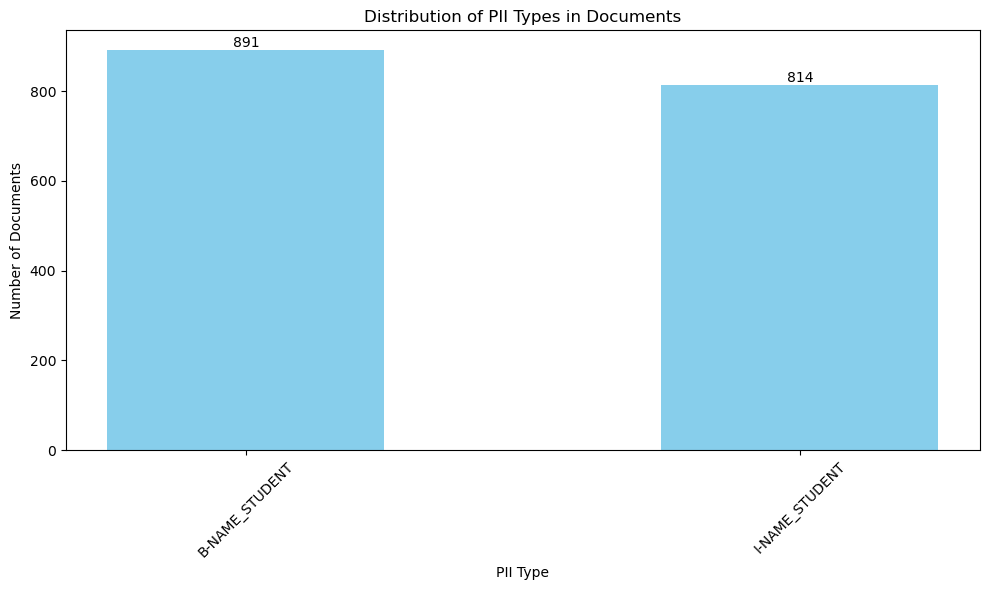

In [52]:
# Define the list of PII types to count
pii_types = ['B-NAME_STUDENT', 'I-NAME_STUDENT']

# Count the number of documents containing each PII type
pii_counts = {pii: sum(pii in labels for labels in train['labels']) for pii in pii_types}

# Convert the counts to a DataFrame for easier plotting
pii_counts_df = pd.DataFrame(list(pii_counts.items()), columns=['PII Type', 'Document Count'])

# Plot the distribution of PII types
plt.figure(figsize=(10, 6))
bars = plt.bar(pii_counts_df['PII Type'], pii_counts_df['Document Count'], color='skyblue', width = 0.5)

# Add counts on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(height), ha='center', va='bottom')

plt.xlabel('PII Type')
plt.ylabel('Number of Documents')
plt.title('Distribution of PII Types in Documents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()